### How to do a clip :)

In [8]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load CSV into a DataFrame
alloaks = pd.read_csv('Group Data/AllOaksinLACounty.csv')

# Check column names to ensure they contain latitude and longitude
print(alloaks.columns)

# Replace 'latitude' and 'longitude' with the actual column names in your CSV
gdf = gpd.GeoDataFrame(alloaks, geometry=gpd.points_from_xy(alloaks['longitude'], alloaks['latitude']))

# Set the coordinate reference system (CRS) to WGS84 (EPSG:4326)
gdf.set_crs(epsg=4326, inplace=True)

# Display the GeoDataFrame
print(gdf.head())


Index(['id', 'observed_on', 'latitude', 'longitude', 'place_town_name',
       'place_county_name', 'scientific_name', 'common_name'],
      dtype='object')
      id observed_on   latitude   longitude place_town_name place_county_name  \
0   8010  2010-08-08  34.051315 -118.828232             NaN       Los Angeles   
1  16226  2011-04-21  34.099908 -118.723948             NaN       Los Angeles   
2  49531  2012-01-29  34.037792 -118.750244             NaN       Los Angeles   
3  52936  2012-02-21  34.210906 -118.122473             NaN       Los Angeles   
4  57187  2012-03-06  34.193470 -118.175340             NaN       Los Angeles   

          scientific_name           common_name                     geometry  
0  Quercus berberidifolia  California scrub oak  POINT (-118.82823 34.05132)  
1          Quercus lobata            valley oak  POINT (-118.72395 34.09991)  
2       Quercus agrifolia        coast live oak  POINT (-118.75024 34.03779)  
3     Quercus chrysolepis       canyon l

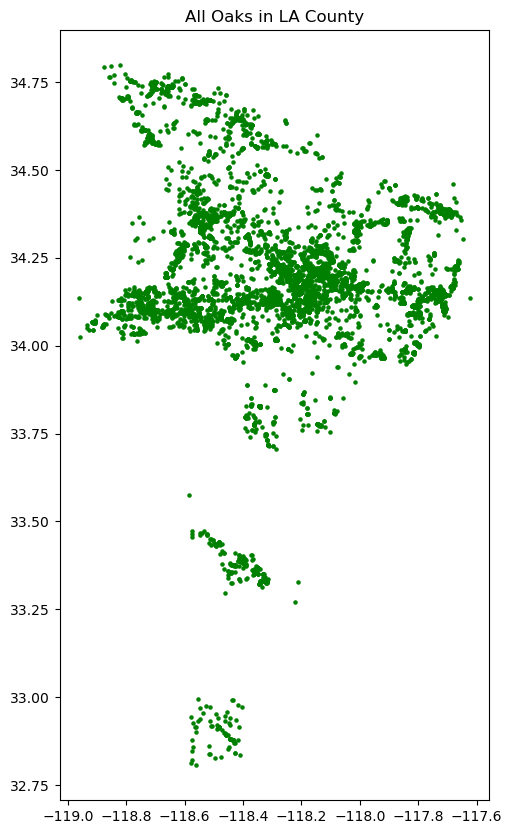

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
gdf.plot(marker='o', color='green', markersize=5, figsize=(10, 10))

# Add title and show the plot
ax.set_xticks([])
ax.set_yticks([])
plt.title("All Oaks in LA County")
plt.grid(False)
plt.show()


In [13]:
# Load the Altadena boundary GeoJSON
altadena_boundary = gpd.read_file('Group Data/altadena_boundary.geojson')

# Ensure both datasets have the same CRS
gdf = gdf.to_crs(altadena_boundary.crs)

# Clip the oak trees to the Altadena boundary
gdf_clipped = gpd.clip(gdf, altadena_boundary)

# Display the clipped GeoDataFrame
print(gdf_clipped.head())

# Optional: Save to a new file
gdf_clipped.to_file('Group Data/AllOaks_Altadena.geojson', driver='GeoJSON')


              id observed_on   latitude   longitude place_town_name  \
4258    67496134  2021-01-02  34.170654 -118.100380        Altadena   
6674   142886389  2022-11-24  34.171722 -118.113416             NaN   
57        197588  2013-02-13  34.174273 -118.104555             NaN   
3902    51830274  2020-06-28  34.176753 -118.107886        Altadena   
10613  255084178  2024-12-12  34.174864 -118.097442        Altadena   

      place_county_name         scientific_name           common_name  \
4258        Los Angeles       Quercus agrifolia        coast live oak   
6674        Los Angeles  Quercus berberidifolia  California scrub oak   
57          Los Angeles       Quercus agrifolia        coast live oak   
3902        Los Angeles     Quercus engelmannii         Engelmann oak   
10613       Los Angeles       Quercus agrifolia        coast live oak   

                          geometry  
4258   POINT (-118.10038 34.17065)  
6674   POINT (-118.11342 34.17172)  
57     POINT (-118.1045

#### Maps

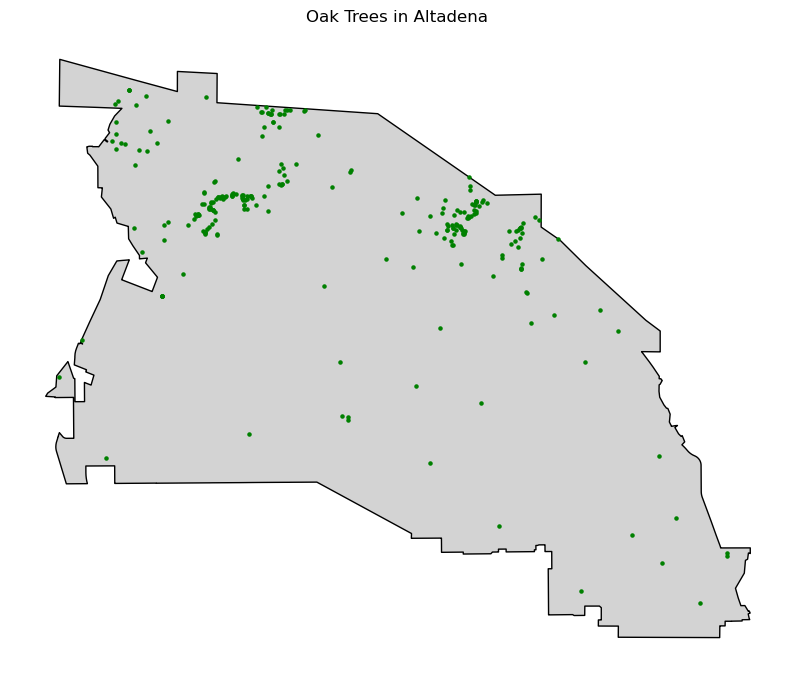

In [14]:
# Plot the boundary and clipped trees
fig, ax = plt.subplots(figsize=(10, 10))
altadena_boundary.plot(ax=ax, color='lightgray', edgecolor='black')  # Plot Altadena boundary
gdf_clipped.plot(ax=ax, marker='o', color='green', markersize=5)  # Plot clipped oak trees

# Remove axis labels and grid
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Add title
plt.title("Oak Trees in Altadena")

# Show the plot
plt.show()

In [17]:
import folium

# Get the center of the clipped data for better map focus
map_center = [gdf_clipped['latitude'].mean(), gdf_clipped['longitude'].mean()]

# Create the map
m = folium.Map(location=map_center, zoom_start=13)

# Add Altadena boundary as a polygon
folium.GeoJson(altadena_boundary, name="Altadena Boundary", style_function=lambda x: {
    "fillColor": "gray",
    "color": "black",
    "weight": 2,
    "fillOpacity": 0.2
}).add_to(m)

# Add individual oak tree markers
for _, row in gdf_clipped.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=row.get('Tree_Name', 'Oak Tree'),  # Replace 'Tree_Name' with the correct column if needed
        icon=folium.Icon(color='green')
    ).add_to(m)

# Save and display the map
m.save("Clipped_Oak_Trees_Map.html")
m


In [21]:
import folium

# Ensure gdf_clipped is not empty
if not gdf_clipped.empty:
    # Get the center of the clipped data for better map focus
    map_center = [gdf_clipped['latitude'].mean(), gdf_clipped['longitude'].mean()]
    
    # Create the map
    m = folium.Map(location=map_center, zoom_start=13)

    # Add Altadena boundary as a polygon
    folium.GeoJson(altadena_boundary, name="Altadena Boundary", style_function=lambda x: {
        "fillColor": "gray",
        "color": "black",
        "weight": 2,
        "fillOpacity": 0.2
    }).add_to(m)

    # Add individual oak tree markers with a tree icon
    for _, row in gdf_clipped.iterrows():
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=f"Tree: {row.get('Tree_Name', 'Oak Tree')}",  # Replace 'Tree_Name' if needed
            icon=folium.Icon(icon="tree", prefix="fa", color="darkgreen")  # Correct FontAwesome tree icon
        ).add_to(m)
else:
    print("No trees found in the Altadena boundary!")

# Save and display the map
m.save("Clipped_Oak_Trees_Map.html")
m


Alternatively we can run code that looks like this. This may be easier. 

/tmp/ipykernel_912/2412749923.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_altadena_oak = gdf_oak[gdf_oak.within(altadena_boundary.unary_union)]


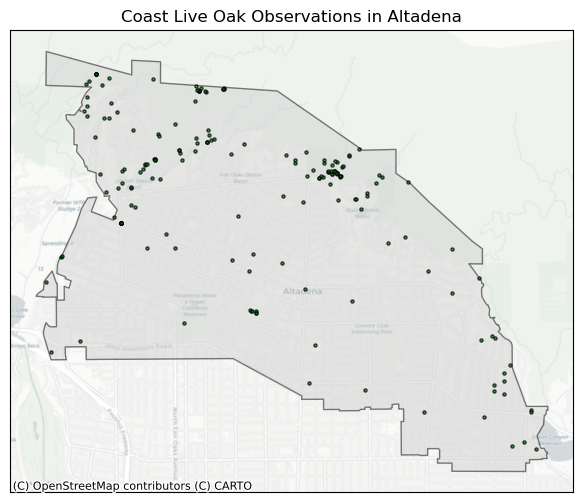

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

# 1️⃣ Load Coast Live Oak observations (CSV)
df_oak = pd.read_csv("Group Data/coastliveoaksobservations.csv")

# Convert to GeoDataFrame (assumes latitude and longitude columns exist)
gdf_oak = gpd.GeoDataFrame(df_oak, geometry=gpd.points_from_xy(df_oak.longitude, df_oak.latitude), crs="EPSG:4326")

# 2️⃣ Load Altadena boundary (GeoJSON)
altadena_boundary = gpd.read_file("Group Data/altadena_boundary.geojson")

# 3️⃣ Ensure CRS matches
altadena_boundary = altadena_boundary.to_crs(gdf_oak.crs)

# 4️⃣ Spatial Join: Keep only observations inside Altadena
gdf_altadena_oak = gdf_oak[gdf_oak.within(altadena_boundary.unary_union)]

# 5️⃣ Plot the overlay
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Altadena boundary
altadena_boundary.plot(ax=ax, color="lightgray", edgecolor="black", alpha=0.5)

# Plot Coast Live Oak observations (green dots)
gdf_altadena_oak.plot(ax=ax, marker="o", color="green", markersize=5, alpha=0.7, edgecolor="black")

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=gdf_oak.crs)

# Formatting
ax.set_title("Coast Live Oak Observations in Altadena")
ax.set_xticks([])
ax.set_yticks([])

# Show the plot
plt.show()